# Data Initialization


In [33]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

raw_df = pd.read_csv('weekly_player_stats_offense.csv')
rng = np.random.RandomState(seed=67)

In [34]:
# initial values for labels of features to be used or excluded by model
categorical_features = set([])
real_val_features = set([])
features_dropped = set([]) # remove from lists of kept features
target_labels = set(['fantasy_points_ppr'])


#print(target_labels)
#print("Categorical Features: ", categorical_features)
#print("Numerical Features: ", real_val_features)

In [35]:
for col in raw_df.columns :
    if pd.api.types.is_numeric_dtype(raw_df[col]) :
        real_val_features.add(col)
    else :
        categorical_features.add(col)

#print(categorical_features)
#print(real_val_features)

In [36]:
# ensure target or potential target labels are dropped from model input df
for label in raw_df :
    label = str(label)
    if 'fantasy' in label :
        features_dropped.add(label)


In [37]:
# set fantasy points as targets 
# drop irrelevant / categorical features 
# condense samples to one per player - seasonal weekly average 
# make training-validation split 
# encode / normalize kept features 
# train / validate model 
# Remove features that have minimal impact on model performance 
# whatever the fuck else

# Categorical Stats
# position

# Numerical Stats
# week
# season
# passing_yards
# receiving_yards
# rushing_yards
# rush_touchdown
# pass_touchdown
# fumble_lost
# receptions
# interception

# Logically, we split the fantasy point stats between test and training and compare them against our model
# Target = fantasy_points_ppr

# plot each categorical feature and numerical feature
# find and fill holes or remove if missing too much data

# create test dataframe
# test_df = pd.concat(raw_df[catgeorical] , raw_df[real_value])

# ohe categorical features
# normalize numerical features

# train test split
	# split based on avverge fantasy points ppr? or some other metric ? 

# stick into a model - xgboost / random forest / linear regression

# graph model perofrmances, start selecting features based on importance, correlation, etc to combine or remove 

#plt.figure(dpi=500)
#sns.heatmap(position_filtered_df.isnull() , cbar=False , cmap='viridis')
#plt.ylabel('Samples')
#plt.xlabel('Features')

#plt.show()

137


Text(0.5, 118.61111111111106, 'Features')

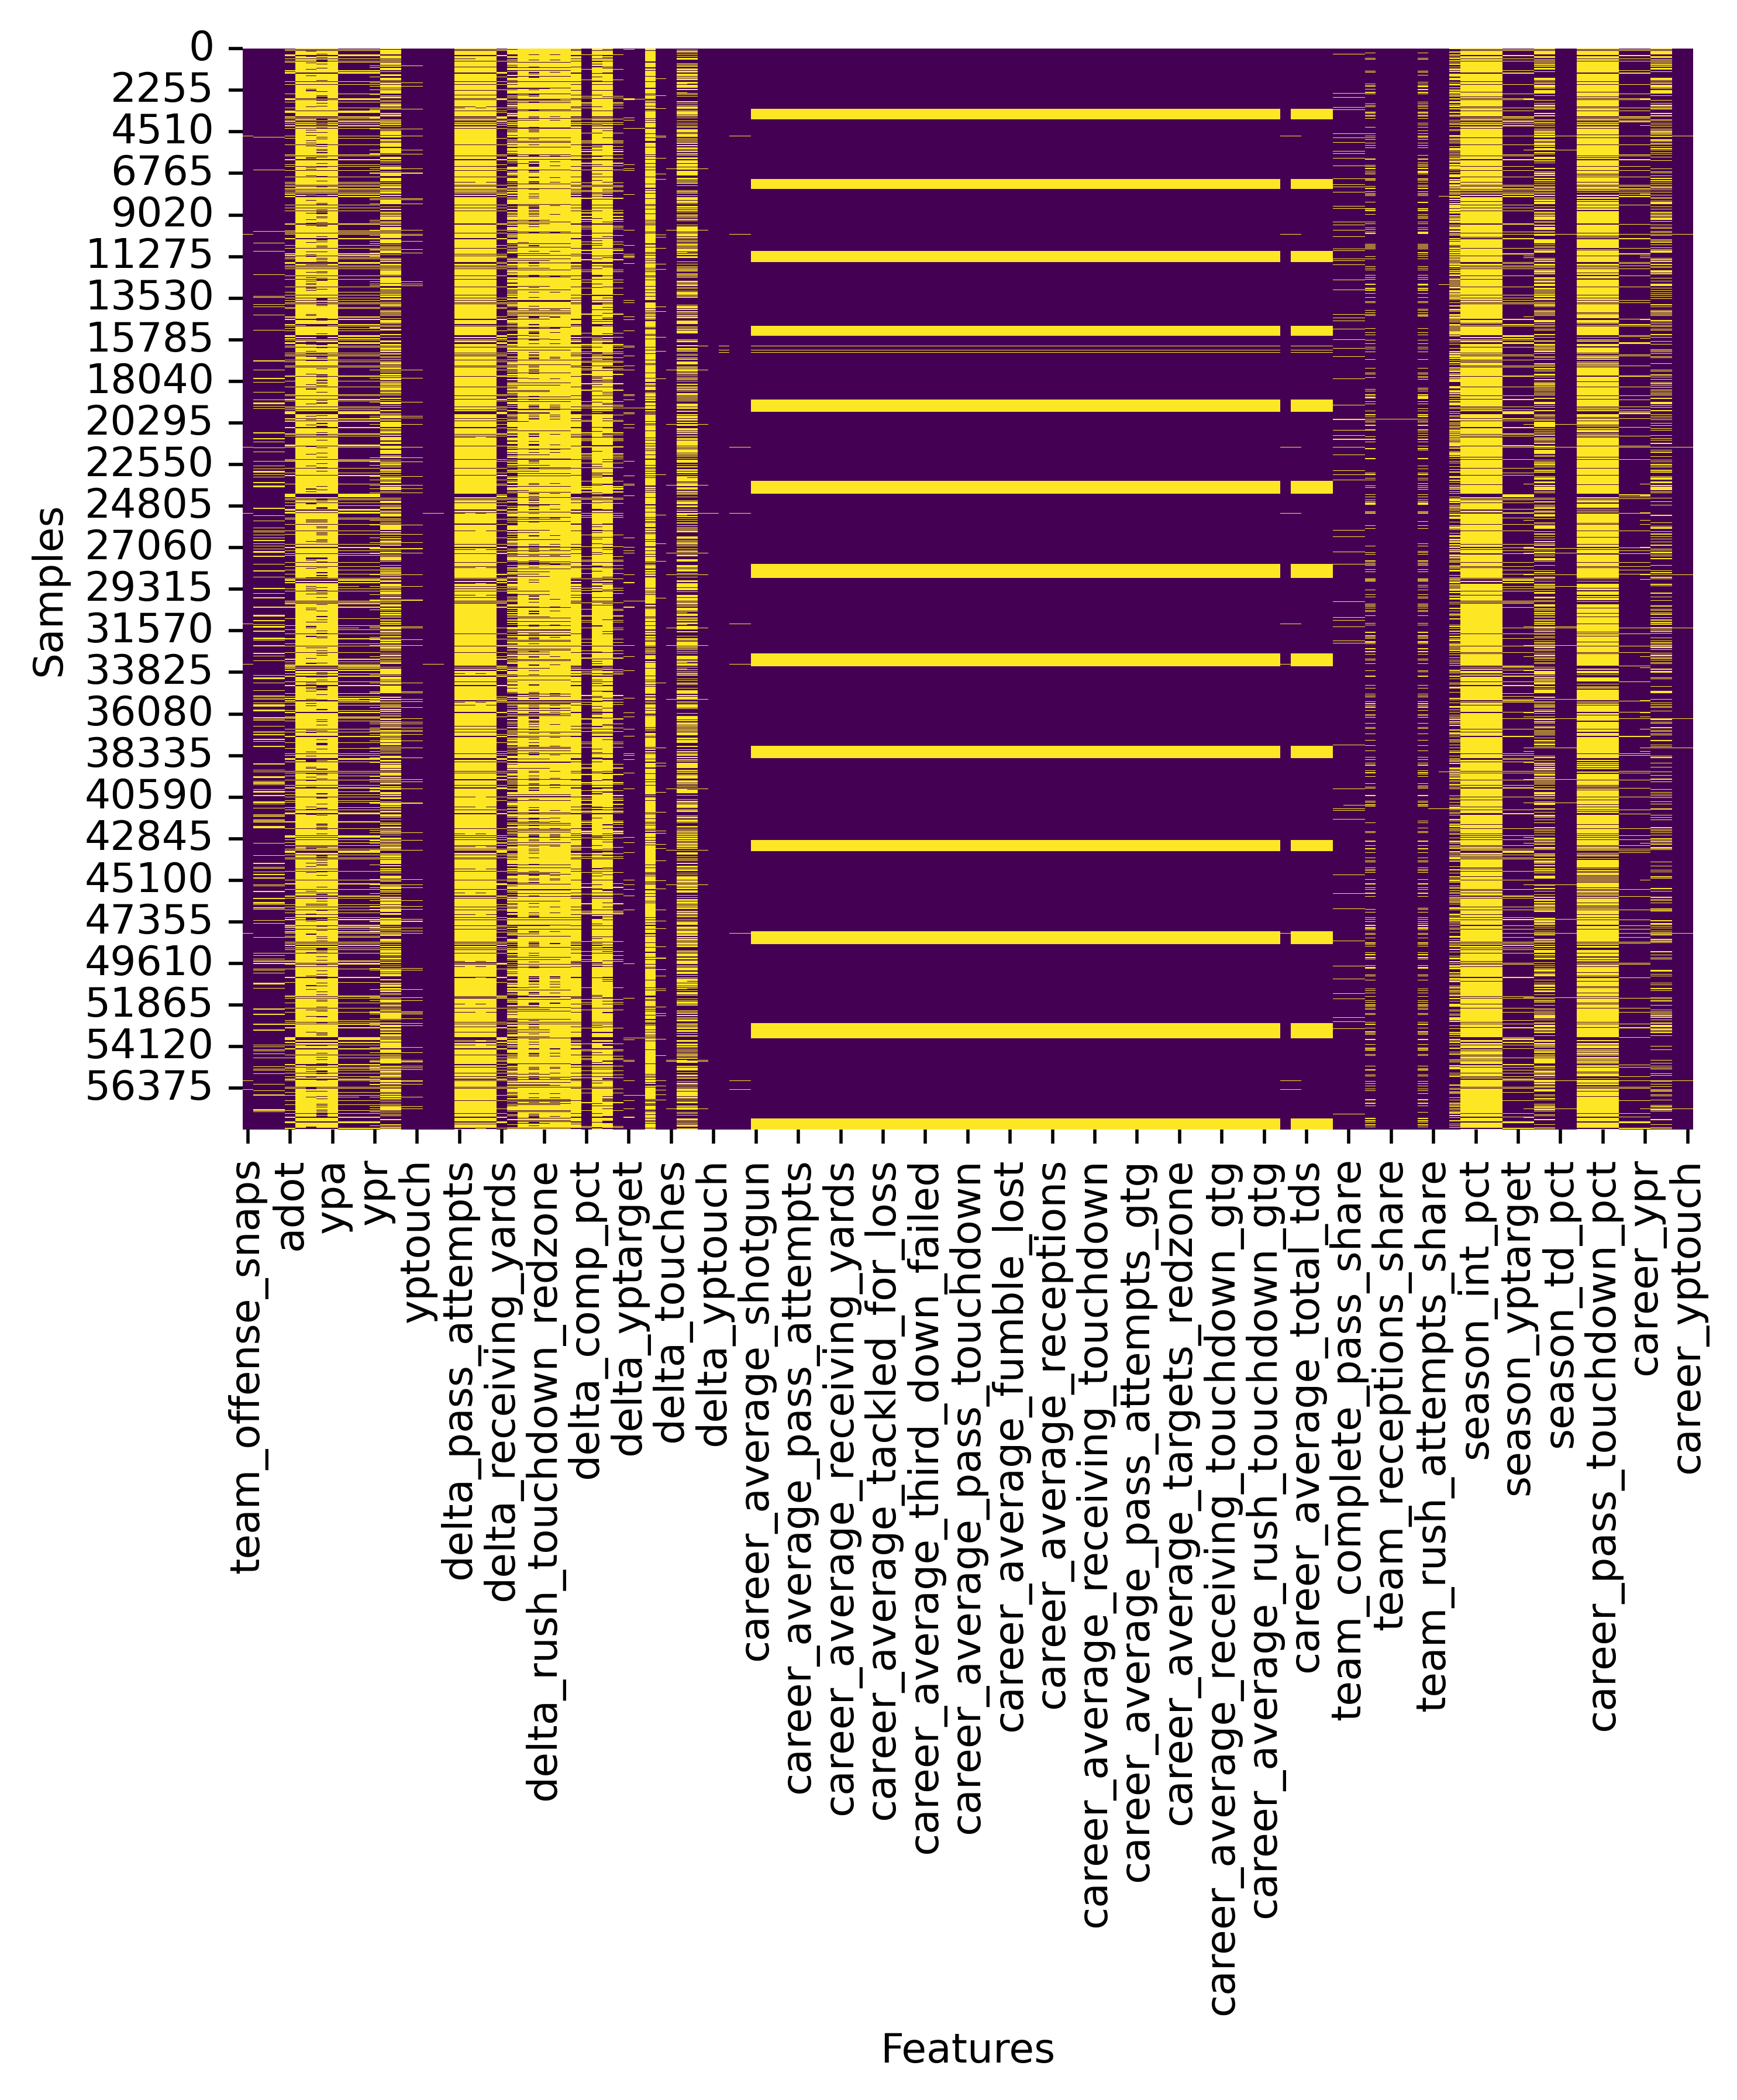

In [38]:
temp = raw_df.drop(features_dropped, axis=1)
missing_values = temp.columns[temp.isnull().any()]
print(len(missing_values))

plt.figure(dpi=500)
sns.heatmap(raw_df[list(missing_values)].isnull(), cbar=False , cmap='viridis')
plt.ylabel('Samples')
plt.xlabel('Features')
#plt.show()

In [39]:

# add features with more than missing_threshold% missing data to drop features_list
missing_fractions = raw_df[list(missing_values)].isnull().mean() 
missing_threshold = missing_fractions.mean()

print(f'Removing features with less than {missing_threshold}% missing values')
potential_drop = missing_fractions[missing_fractions > missing_threshold].index
print(len(potential_drop))
print(len(features_dropped))
features_dropped.update(potential_drop)
print(len(features_dropped))


Removing features with less than 0.26780586025724296% missing values
36
12
48


In [ ]:
# Skye: Fills empty datafields with the average value for that field
for feature in raw_df:
    if feature not in features_dropped:
        raw_df[feature] = raw_df[feature].fillna(np.mean(raw_df[feature].dropna()))

<bound method NDFrame.head of        season  week  offense_snaps  offense_pct  team_offense_snaps  \
0        2012    12           63.0         1.00                63.0   
1        2012    13           66.0         1.00                66.0   
2        2012     2           12.0         0.18                67.0   
3        2012     3            4.0         0.05                80.0   
4        2012     4           18.0         0.26                69.0   
...       ...   ...            ...          ...                 ...   
58624    2024    10           16.0         0.27                59.0   
58625    2024    12            9.0         0.16                56.0   
58626    2024    13           13.0         0.16                81.0   
58627    2024    14           10.0         0.14                71.0   
58628    2024    15           11.0         0.16                69.0   

        player_id  birth_year  draft_year  draft_round  draft_pick  ...  \
0      00-0000865        1974      1998.0 

TypeError: Could not convert string '00-000086500-000086500-000454100-000454100-000454100-000454100-000454100-000454100-000454100-000454100-000454100-000610100-000610100-000610100-000610100-000610100-000610100-000610100-000610100-000610100-000610100-000610100-000610100-000610100-000610100-000610100-000610100-000610100-000610100-000709100-000709100-000709100-000709100-000709100-000709100-000709100-000709100-001034600-001034600-001034600-001034600-001034600-001034600-001034600-001034600-001034600-001034600-001034600-001034600-001034600-001034600-001034600-001034600-001034600-001175400-001175400-001175400-001175400-001175400-001175400-001175400-001175400-001175400-001175400-001175400-001175400-001175400-001175400-001175400-001175400-001175400-001175400-001175400-001575400-001575400-001575400-001575400-001575400-001575400-001575400-001575400-001575400-001575400-001575400-001575400-001575400-001575400-001575400-001959600-001959600-001959600-001959600-001959600-001959600-001959600-001959600-

(58629, 101)


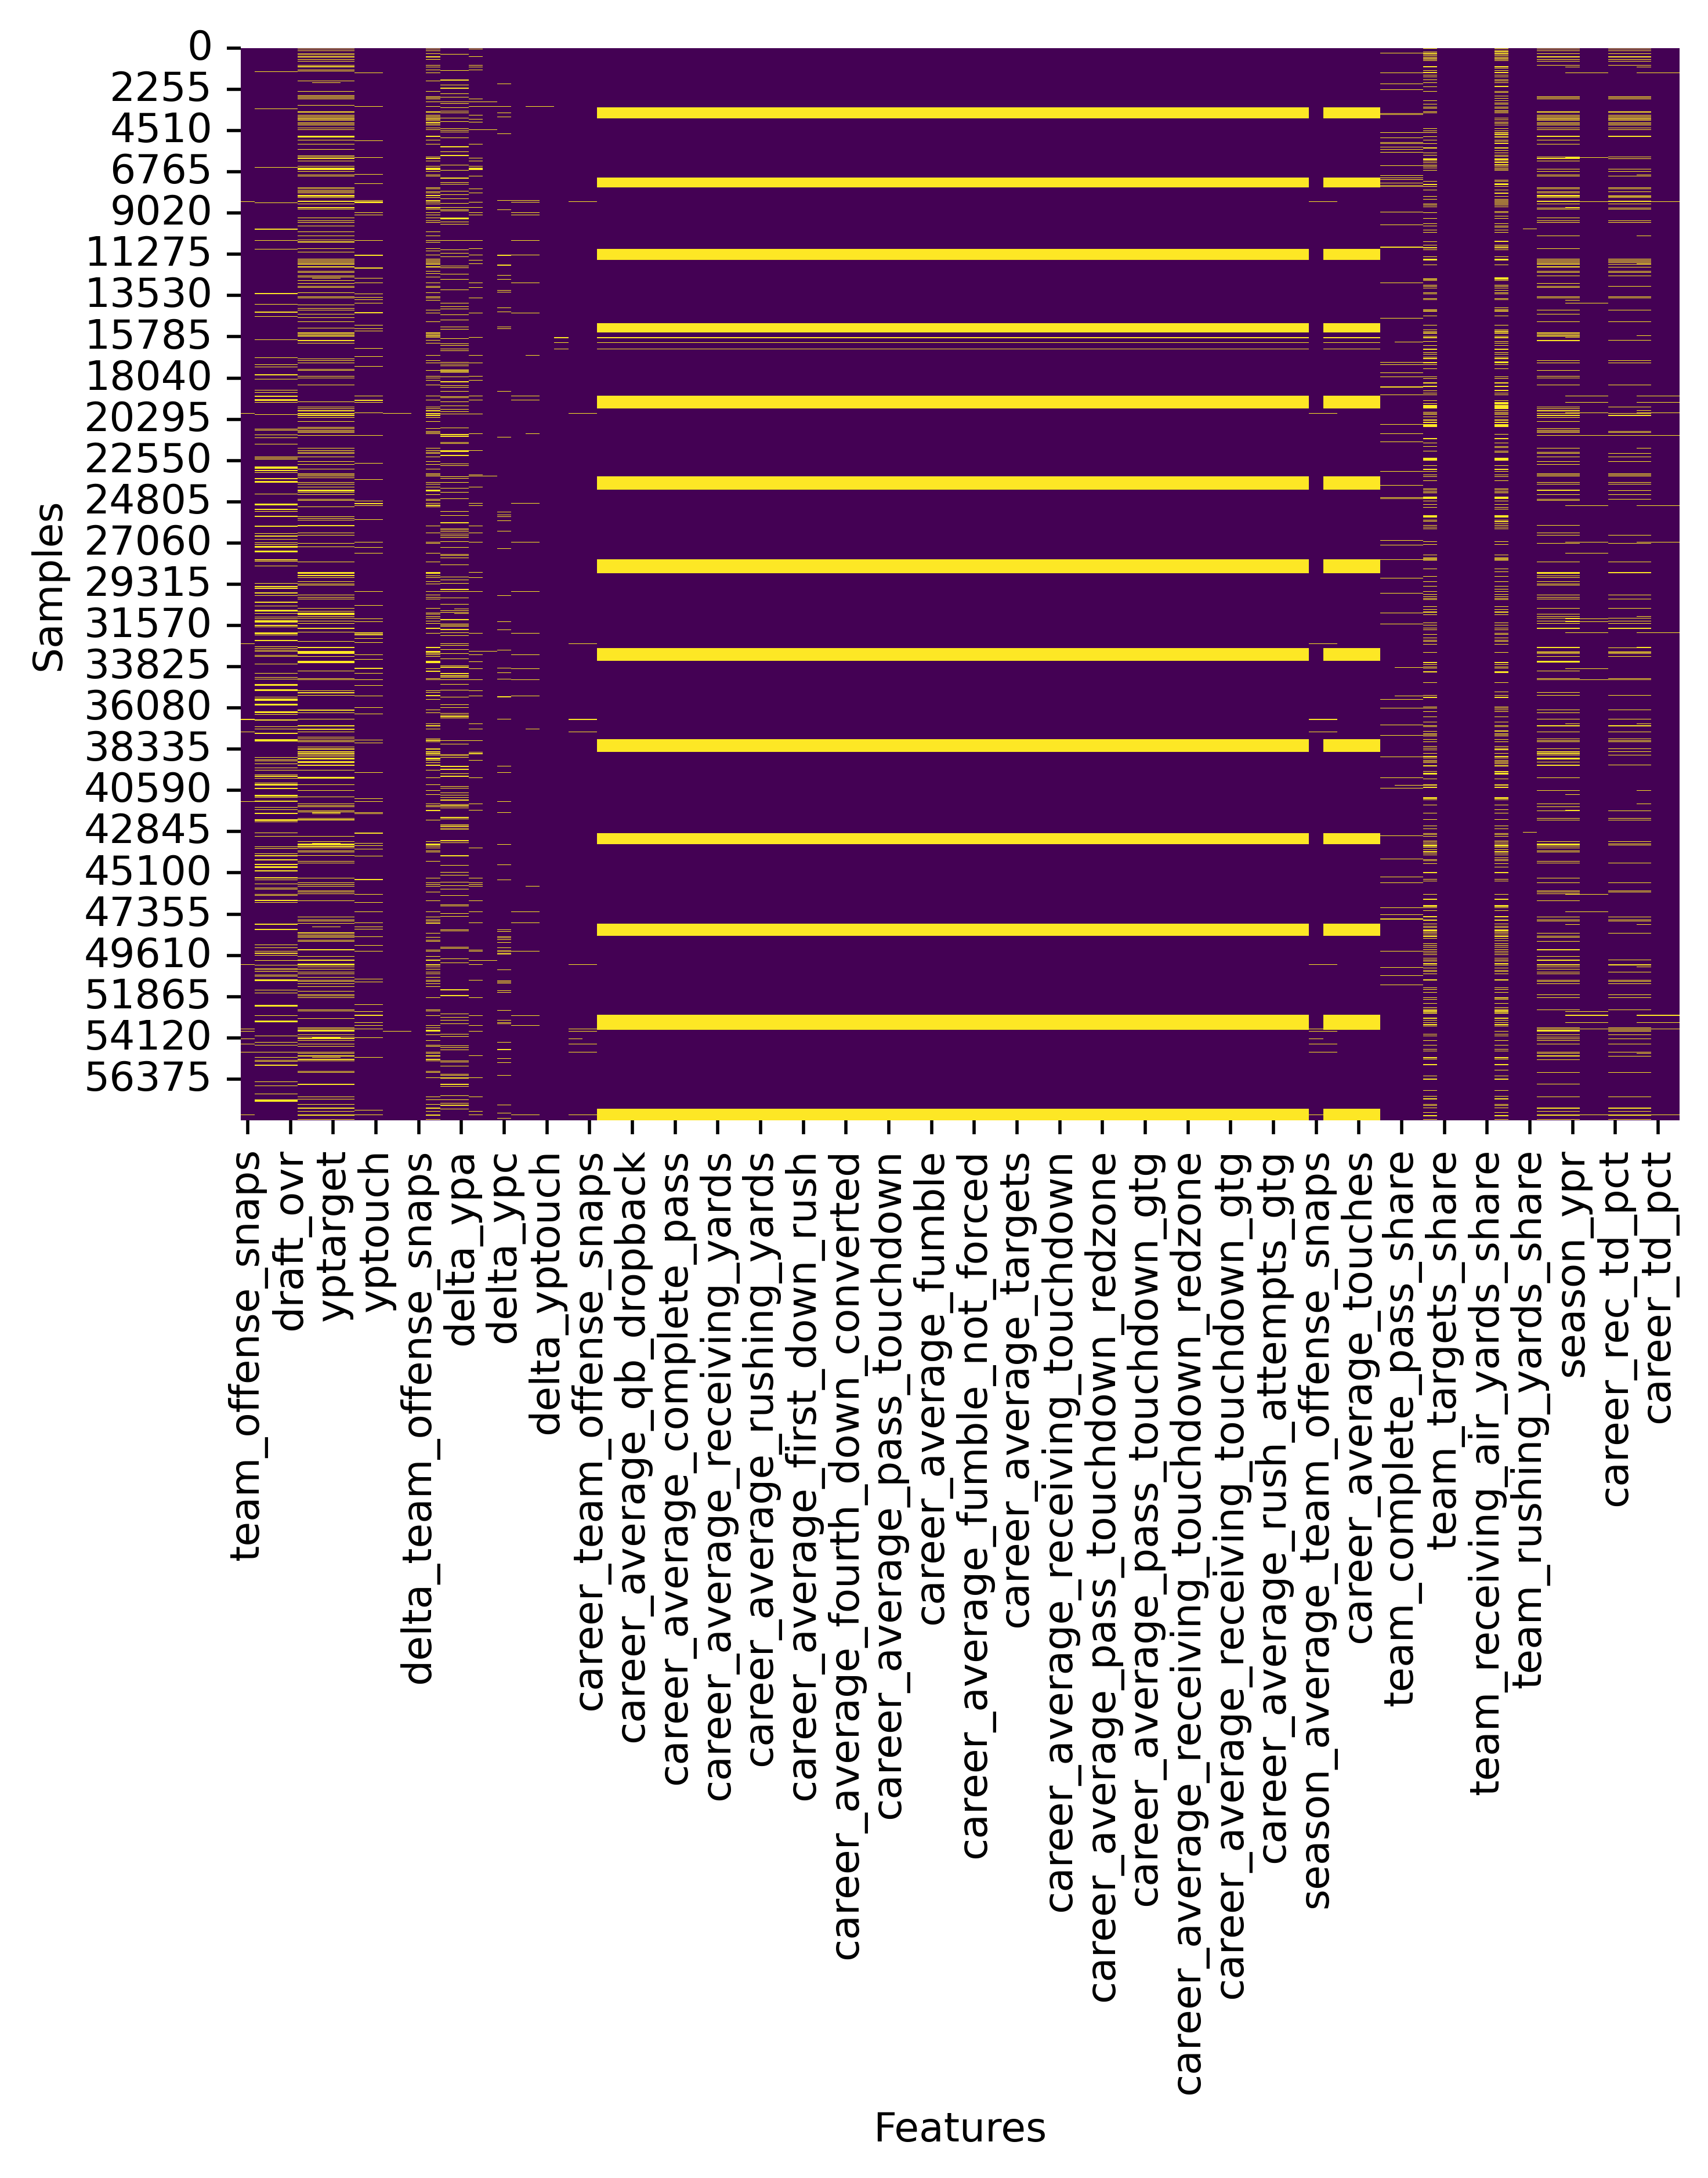

In [ ]:
#Print the 
temp = raw_df.drop(features_dropped, axis=1)
temp = temp[temp.columns[temp.isna().any()]]
print(temp.shape)
plt.figure(dpi=500)
sns.heatmap(temp.isnull(), cbar=False , cmap='viridis')
plt.ylabel('Samples')
plt.xlabel('Features')
plt.show()

In [ ]:
# THIS MUST BE RUN BEFORE TRAINING RUNNING MODEL OR SPLITTING DATAFRAME
# ensure feature lists are cohesive
for label in features_dropped :
    if label in categorical_features :
        categorical_features.remove(label)
    elif label in real_val_features :
        real_val_features.remove(label)
#TODO  OHE AND NORMALIZE categorical features 
input_df = raw_df.drop(list(features_dropped), axis=1)
#OHE(input_df[categorical_features])
#NORMALIZE(input_df(real_val features))


In [ ]:
# The code below creates dataframes filtered by position and drops features with missing values and plots the heat map for each position
# We only want QB, RB, WR, TE
positions = ['QB', 'RB', 'WR', 'TE']
position_filtered_dfs = {}
for position in positions:
	position_df = raw_df[raw_df['position'] == position]
	missing_fraction = position_df.isnull().mean()
	features_to_drop = missing_fraction[missing_fraction > missing_threshold].index

	# Change by Trevor: Added functionality with code from above to drop fantasy features
	all_drops = set(features_to_drop).union(features_dropped)
	position_filtered_df = position_df.drop(columns=list(all_drops))
	position_filtered_dfs[position] = position_filtered_df
	print(f"Dropped features for position {position} due to missing values: ")
	for line in features_to_drop.tolist() :
		print(f"{line}")
	# Print the heatmap of the position filtered dataframe numerical features
	position_features = [col for col in position_filtered_df.columns if not col == 'position']
	print(f"Position {position} Filtered DataFrame Features: ", position_features)
	# plt.figure(dpi=500)
	# sns.heatmap(position_filtered_df[position_features].isnull() , cbar=False , cmap='viridis')
	# plt.title(f'Position: {position}')
	# plt.ylabel('Samples')
	# plt.xlabel('Features')
	# plt.show()

Dropped features for position QB due to missing values: 
adot
rec_td_pct
yptarget
ayptarget
ypr
delta_receiving_yards
delta_rush_touchdown
delta_rush_attempts_redzone
delta_rush_touchdown_redzone
delta_rush_attempts_gtg
delta_rush_touchdown_gtg
delta_rush_td_pct
team_rush_touchdown_share
season_rec_td_pct
season_yptarget
season_ypr
career_rec_td_pct
career_yptarget
career_ypr
Position QB Filtered DataFrame Features:  ['season', 'week', 'offense_snaps', 'offense_pct', 'team_offense_snaps', 'player_id', 'birth_year', 'draft_year', 'draft_round', 'draft_pick', 'draft_ovr', 'height', 'weight', 'college', 'season_type', 'player_name', 'depth_team', 'conference', 'division', 'team', 'shotgun', 'no_huddle', 'qb_dropback', 'qb_scramble', 'pass_attempts', 'complete_pass', 'incomplete_pass', 'passing_yards', 'receiving_yards', 'yards_after_catch', 'rush_attempts', 'rushing_yards', 'tackled_for_loss', 'first_down_pass', 'first_down_rush', 'third_down_converted', 'third_down_failed', 'fourth_down_

In [ ]:
# Below is the code implementation of a model that can predict fantasy points based on player stats
qb_df = position_filtered_dfs['QB']
rb_df = position_filtered_dfs['RB']
wr_df = position_filtered_dfs['WR']
te_df = position_filtered_dfs['TE']
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# For the places where there are missing values, we need to fill htem in with the average of that column
for position, df in position_filtered_dfs.items():
	df_copy = df.copy()
	numeric_cols = [df.select_dtypes(include=['number']).columns]
	for col in numeric_cols:
		mean_value = df[col].mean()
		df[col] = df[col].fillna(mean_value)
	position_filtered_dfs[position] = df_copy

# # print how many samples are in each column of a position dataframe
# for position, df in position_filtered_dfs.items():
# 	print(f"Position: {position}")
# 	print(df.count())
# 	print("\n")
	
def train_and_evaluate_model(position_df, position_name) :
	features = position_df.drop(columns=['fantasy_points_ppr', 'position'])
	target = position_df['fantasy_points_ppr']
	real_val_features = features.select_dtypes(include=['number'])
	
	X_train, X_test, y_train, y_test = train_test_split(real_val_features, target, test_size=0.2, random_state=rng)
	
	model = RandomForestRegressor(n_estimators=100, random_state=rng, n_jobs=-1)
	model.fit(X_train, y_train)
	
	y_pred = model.predict(X_test)
	
	mse = mean_squared_error(y_test, y_pred)
	r2 = r2_score(y_test, y_pred)
	
	print(f"Position: {position_name}")
	print(f"Mean Squared Error: {mse}")
	print(f"R^2 Score: {r2}\n")

train_and_evaluate_model(qb_df, 'QB')
train_and_evaluate_model(rb_df, 'RB')
train_and_evaluate_model(wr_df, 'WR')
train_and_evaluate_model(te_df, 'TE')

ModuleNotFoundError: No module named 'sklearn'